# Example runs of OAC with different model and species settings

In [1]:
# --- Base OAC RUNS ---
# using numpy 2.3.1 instead of 2.2.6
# had to redownload h5netcdf
import numpy as np
from oac_climate_model import OpenAirClim
from pandas import read_csv
from aviation_climate_simulation import AviationClimateSimulation
from aerocm.utils.functions import plot_simulation_results
from oac.utils.utility import load_species_inventory
from aerocm.climate_models.oac.utils.utility import time_norm_ncdf
import matplotlib.pyplot as plt

In [2]:
# --- Set parameters --- 
start_year = 1940
end_year = 2019
species_inventory = load_species_inventory(start_year,end_year,"OAC")

# Testing "Step" in model settings

In [3]:
model_settings = {"step": 1,
                  "scaling" : ""
                 }
species_settings = { "CO2" :{"ratio_erf_rf":  1.0} , 
                                      "Contrails" :{"ratio_erf_rf": 1.0} ,
                                      "NOx" : {"ratio_erf_rf": 1.0},
                                      "H2O" : {"ratio_erf_rf": 1.0} , 

    }

Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_2000.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_2010.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_2020.nc
TOML file written to oac_run.toml
read_config ln. 254 in check_against_template INFO: Get default value for: responses CO2 rf method 
read_config ln. 254 in check_against_template INFO: Get default value for: responses cont method 
read_config ln. 500 in check_metrics_time WARNING: Time step in time range is NOT 1.0 years which could produce wrong metrics values.
read_config ln. 183 in check_config INFO: Configuration file checked.
read_config ln. 380 in create_output_dir INFO: Overwrite existing output directory oac_results/
read_netcdf ln. 173 in open_inventories INFO: Emission inventories openend, attribute sections and time constraints checked successfully.
read_netcdf ln. 220 

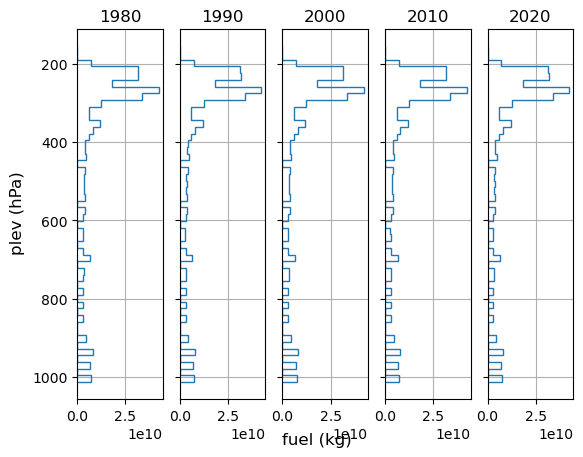

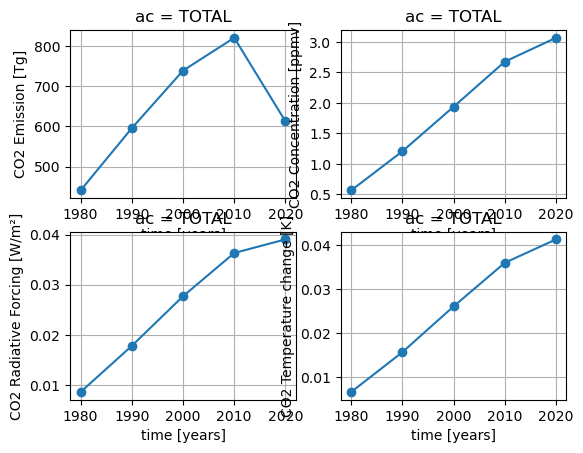

In [13]:
result_co2 = OpenAirClim(start_year, end_year, "CO2", species_inventory["CO2"],species_settings["CO2"], model_settings).run(return_df=True)

Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1981.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1982.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1983.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1984.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1985.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1986.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1987.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1988.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1989.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1991.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1992.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1993.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1994.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1995.nc
Saved sc

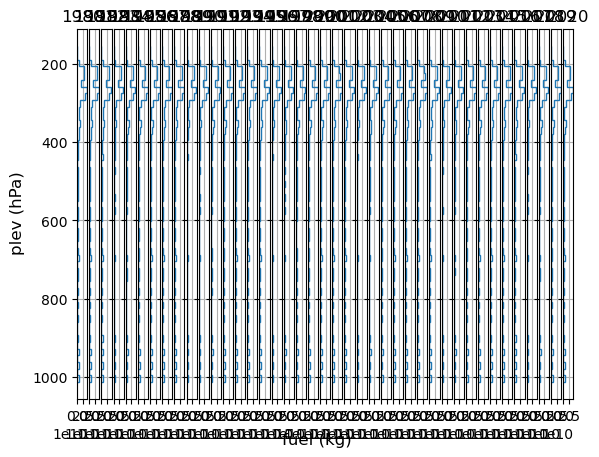

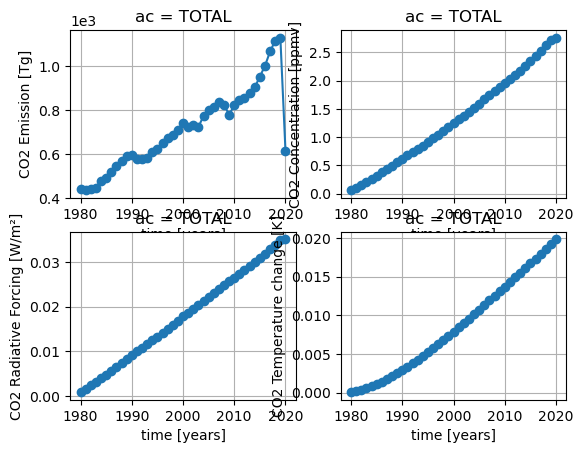

Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1981.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1982.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1983.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1984.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1985.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1986.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1987.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1988.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1989.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1991.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1992.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1993.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1994.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1995.nc
Saved sc

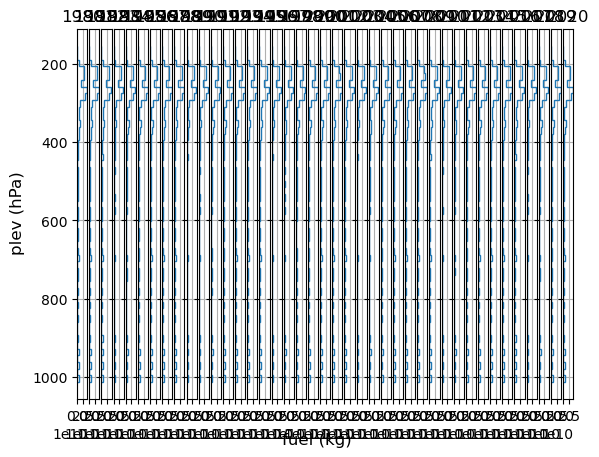

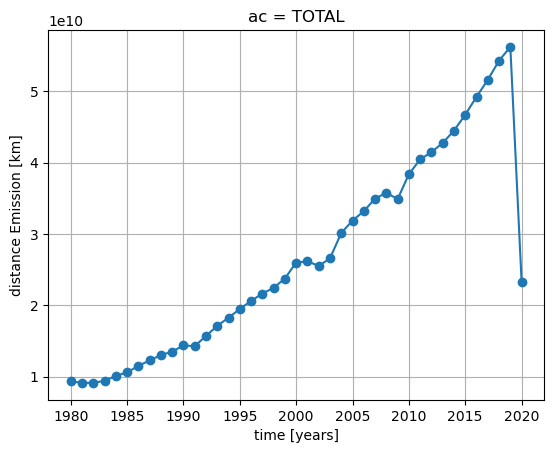

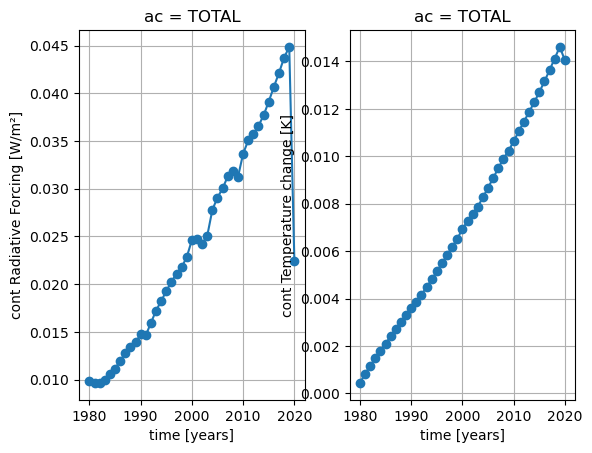

Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1981.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1982.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1983.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1984.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1985.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1986.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1987.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1988.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1989.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1990.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1991.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1992.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1993.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1994.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1995.nc
Saved sc

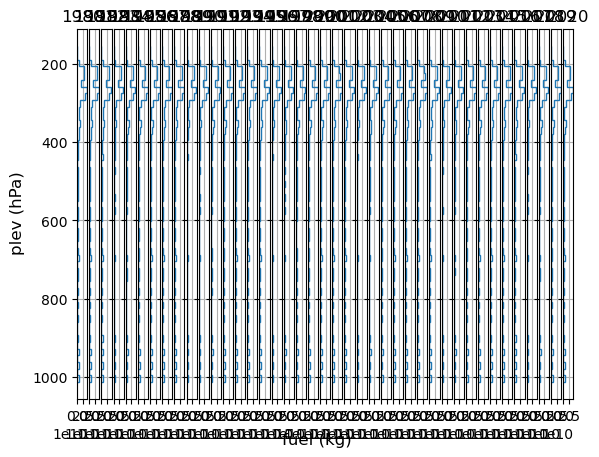

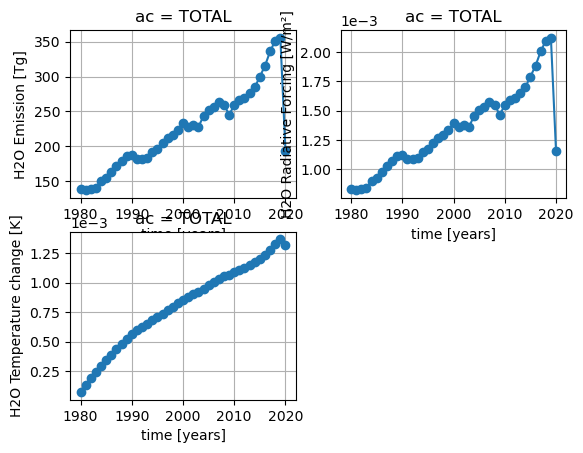

In [4]:
climate_model = 'OAC'
results_full_interpolation = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings, model_settings).run(return_xr = True)

In [5]:
results_full_interpolation

<xarray.Dataset> Size: 4kB
Dimensions:            (species: 5, year: 41)
Coordinates:
  * species            (species) <U9 180B 'CO2' 'Contrails' ... 'Total'
  * year               (year) int64 328B 1980 1981 1982 1983 ... 2018 2019 2020
Data variables:
    radiative_forcing  (species, year) float64 2kB 0.0008642 ... 0.05868
    temperature        (species, year) float64 2kB 6.582e-05 ... 0.03517

<Axes: title={'center': 'Temperature'}, xlabel='Year', ylabel='Temperature'>

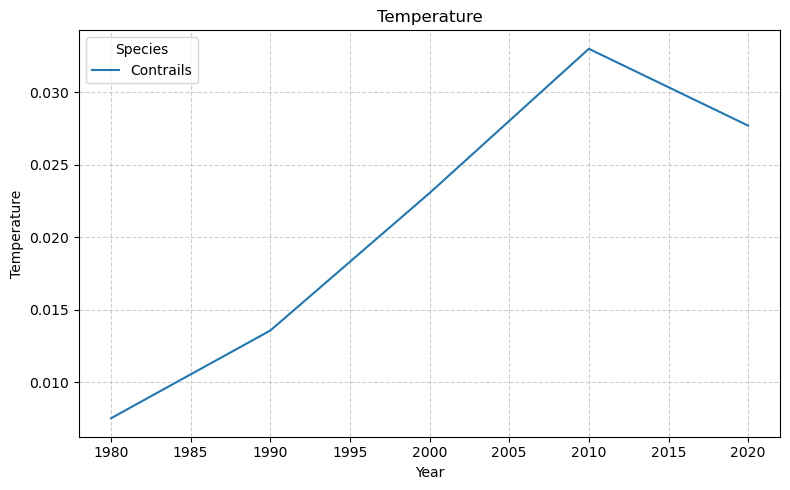

In [16]:
plot_simulation_results(results_full_interpolation, data_var="temperature", species=["Contrails"], stacked=False)

# Testing time norm 

In [6]:
model_settings = {"step" : 1,
                  "scaling" : "norm"
                 }
species_settings = { "CO2" :{"ratio_erf_rf":  1.0} , 
                                      "Contrails" :{"ratio_erf_rf": 1.0} ,
                                      "NOx" : {"ratio_erf_rf": 1.0},
                                      "H2O" : {"ratio_erf_rf": 1.0} , 

    }

In [5]:
climate_model = 'OAC'
results_full = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings, model_settings).run(return_xr = True)

Saved new NetCDF to: time_evo/time_norm_evo.nc
Dataset summary:
<xarray.Dataset> Size: 820B
Dimensions:       (time: 41)
Coordinates:
  * time          (time) int32 164B 1980 1981 1982 1983 ... 2017 2018 2019 2020
Data variables:
    fuel          (time) float32 164B 139.9 137.5 139.3 ... 353.8 357.9 194.4
    EI_CO2        (time) float32 164B 3.15 3.15 3.15 3.15 ... 3.15 3.15 3.15
    EI_H2O        (time) float32 164B 0.9936 0.9936 0.9936 ... 0.9936 0.9936
    dis_per_fuel  (time) float32 164B 0.06683 0.06625 0.06561 ... 0.157 0.1196
Attributes:
    Title:       Time normalization 
    Convention:  CF-XXX
    Type:        norm
    Author:      Abhigyan Prakash based on OAC example


TypeError: Model setting weights must be of type <class 'dict'>

In [8]:
results_full

<xarray.Dataset> Size: 4kB
Dimensions:            (species: 5, year: 41)
Coordinates:
  * species            (species) <U9 180B 'CO2' 'Contrails' ... 'Total'
  * year               (year) int64 328B 1980 1981 1982 1983 ... 2018 2019 2020
Data variables:
    radiative_forcing  (species, year) float64 2kB 0.0008642 ... 0.04998
    temperature        (species, year) float64 2kB 6.582e-05 ... 0.02926

In [9]:
results_full_interpolation

<xarray.Dataset> Size: 4kB
Dimensions:            (species: 5, year: 41)
Coordinates:
  * species            (species) <U9 180B 'CO2' 'Contrails' ... 'Total'
  * year               (year) int64 328B 1980 1981 1982 1983 ... 2018 2019 2020
Data variables:
    radiative_forcing  (species, year) float64 2kB 0.0008642 ... 0.05868
    temperature        (species, year) float64 2kB 6.582e-05 ... 0.03517

NORMALISATION RESULTS


<Axes: title={'center': 'Temperature'}, xlabel='Year', ylabel='Temperature'>

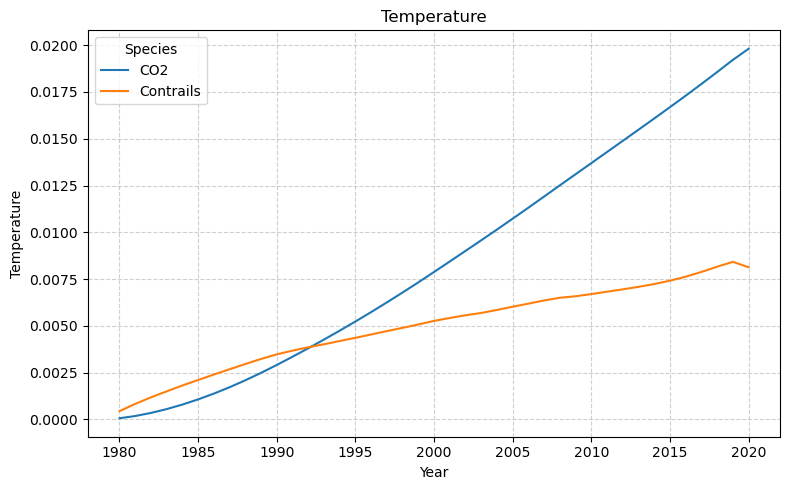

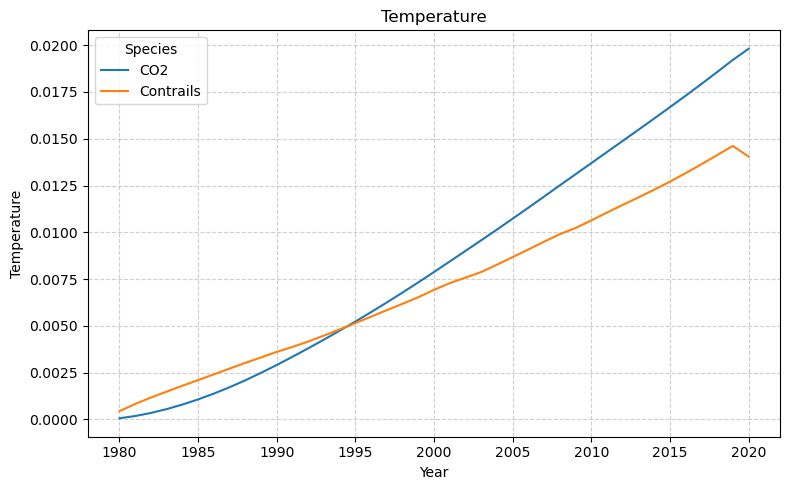

In [12]:
print("NORMALISATION RESULTS")
plot_simulation_results(results_full, data_var="temperature", species=["CO2","Contrails"], stacked=False)

plot_simulation_results(results_full_interpolation, data_var="temperature", species=["CO2", "Contrails"], stacked=False)

# Efficacy

In [3]:
species_settings2 = { "CO2" : {"lambda": 3.73} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 2.59} 
                                      
    }

model_settings = {"step" : 1,
                  "scaling" : "norm"
                 }

Saved new NetCDF to: time_evo/time_norm_evo.nc
Dataset summary:
<xarray.Dataset> Size: 820B
Dimensions:       (time: 41)
Coordinates:
  * time          (time) int32 164B 1980 1981 1982 1983 ... 2017 2018 2019 2020
Data variables:
    fuel          (time) float32 164B 139.9 137.5 139.3 ... 353.8 357.9 194.4
    EI_CO2        (time) float32 164B 3.15 3.15 3.15 3.15 ... 3.15 3.15 3.15
    EI_H2O        (time) float32 164B 0.9936 0.9936 0.9936 ... 0.9936 0.9936
    dis_per_fuel  (time) float32 164B 0.06683 0.06625 0.06561 ... 0.157 0.1196
Attributes:
    Title:       Time normalization 
    Convention:  CF-XXX
    Type:        norm
    Author:      Abhigyan Prakash based on OAC example
{'lambda': 3.73}
Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
TOML file written to oac_run.toml
read_config ln. 254 in check_against_template INFO: Get default value for: responses CO2 rf method 
read_config ln. 254 in check_against_template INFO: Get default value for: responses cont method

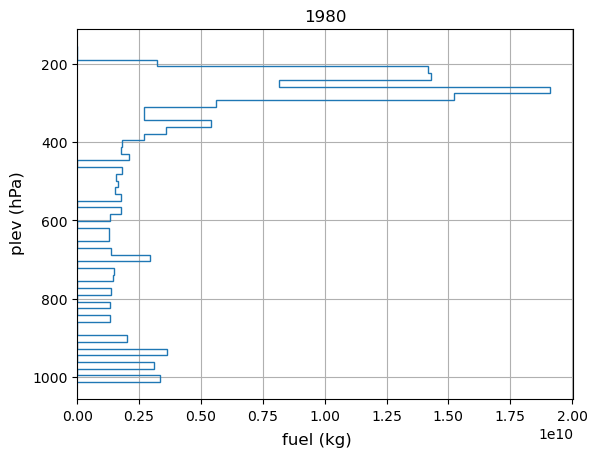

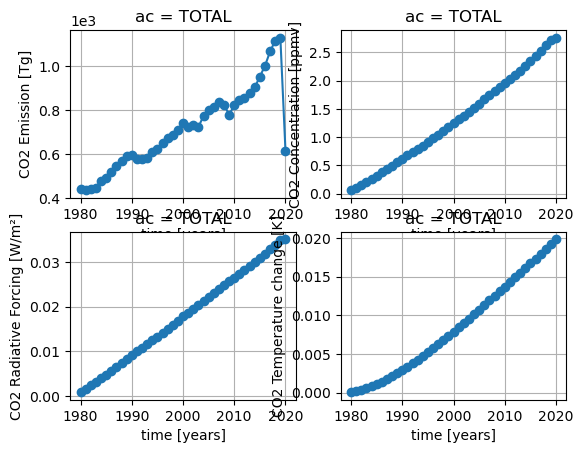

{'efficacy': 2.59}
Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
TOML file written to oac_run.toml
read_config ln. 254 in check_against_template INFO: Get default value for: responses CO2 rf method 
read_config ln. 254 in check_against_template INFO: Get default value for: responses cont method 
read_config ln. 520 in check_metrics_time ERROR: Metrics time settings with t_0 = 1980 and H = 42 are outside defined time range.
read_config ln. 185 in check_config ERROR: Configuration is not valid.
read_config ln. 380 in create_output_dir INFO: Overwrite existing output directory oac_results/
read_netcdf ln. 173 in open_inventories INFO: Emission inventories openend, attribute sections and time constraints checked successfully.
read_netcdf ln. 220 in split_inventory_by_aircraft WARNING: No ac coordinate found in emission inventory for year 1980. Reverting to 'DEFAULT' aircraft from config file.
main ln. 93 in run WARNING: No species defined in config with 0D response_grid.
ma

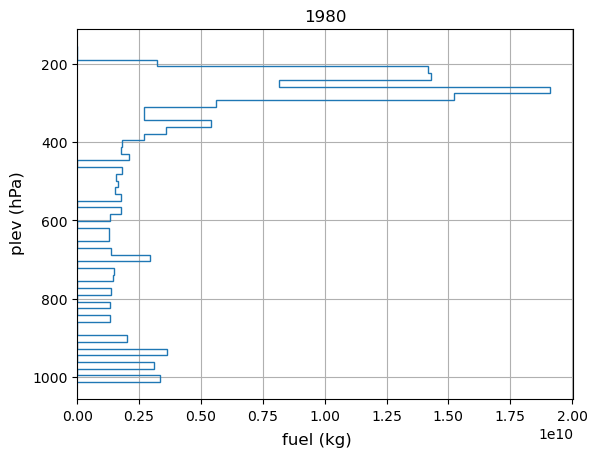

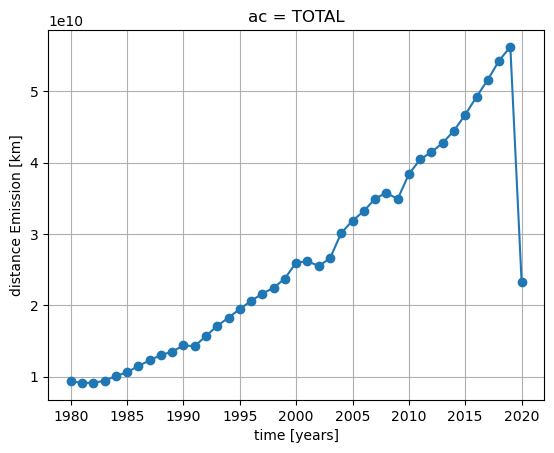

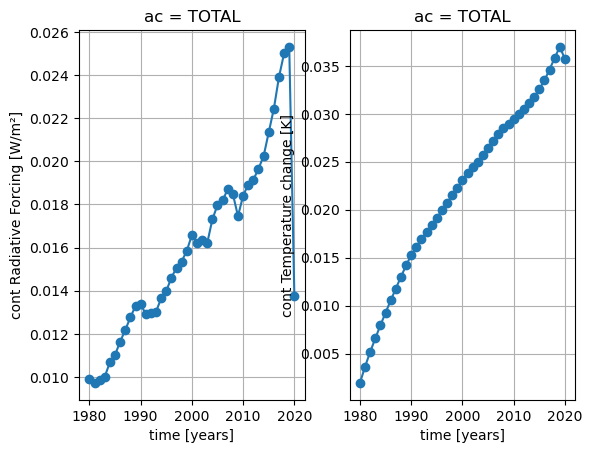

{'efficacy': 1.14}
Saved scaled emissions to oac_inputs/mat_generated_nc_1980.nc
TOML file written to oac_run.toml
read_config ln. 254 in check_against_template INFO: Get default value for: responses CO2 rf method 
read_config ln. 254 in check_against_template INFO: Get default value for: responses cont method 
read_config ln. 520 in check_metrics_time ERROR: Metrics time settings with t_0 = 1980 and H = 42 are outside defined time range.
read_config ln. 185 in check_config ERROR: Configuration is not valid.
read_config ln. 380 in create_output_dir INFO: Overwrite existing output directory oac_results/
read_netcdf ln. 173 in open_inventories INFO: Emission inventories openend, attribute sections and time constraints checked successfully.
read_netcdf ln. 220 in split_inventory_by_aircraft WARNING: No ac coordinate found in emission inventory for year 1980. Reverting to 'DEFAULT' aircraft from config file.
main ln. 93 in run WARNING: No species defined in config with 0D response_grid.
ma

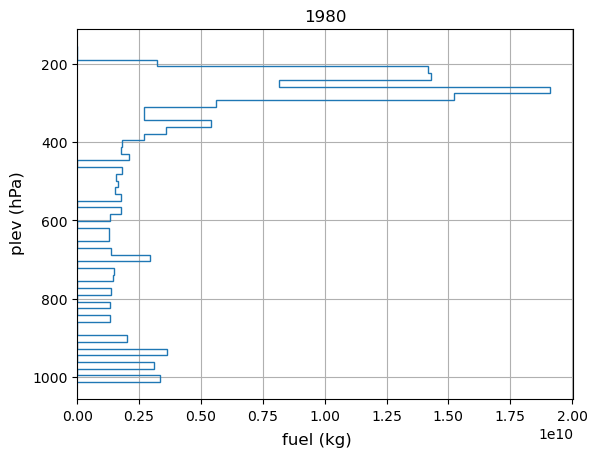

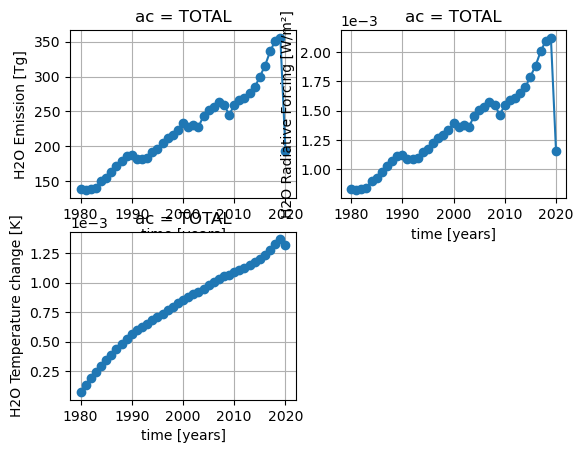

: 

In [5]:
climate_model = 'OAC'
results_co2_373 = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings2, model_settings).run(return_xr = True)

In [11]:
results_cont_std

<xarray.Dataset> Size: 4kB
Dimensions:            (species: 5, year: 41)
Coordinates:
  * species            (species) <U9 180B 'CO2' 'Contrails' ... 'Total'
  * year               (year) int64 328B 1980 1981 1982 1983 ... 2018 2019 2020
Data variables:
    radiative_forcing  (species, year) float64 2kB 0.0008642 ... 0.04998
    temperature        (species, year) float64 2kB 6.582e-05 ... 0.02926

: 

In [14]:
results_cont_ext

<xarray.Dataset> Size: 4kB
Dimensions:            (species: 5, year: 41)
Coordinates:
  * species            (species) <U9 180B 'CO2' 'Contrails' ... 'Total'
  * year               (year) int64 328B 1980 1981 1982 1983 ... 2018 2019 2020
Data variables:
    radiative_forcing  (species, year) float64 2kB 0.0008642 ... 0.04998
    temperature        (species, year) float64 2kB 6.582e-05 ... 0.05684

: 

<Axes: title={'center': 'Temperature'}, xlabel='Year', ylabel='Temperature'>

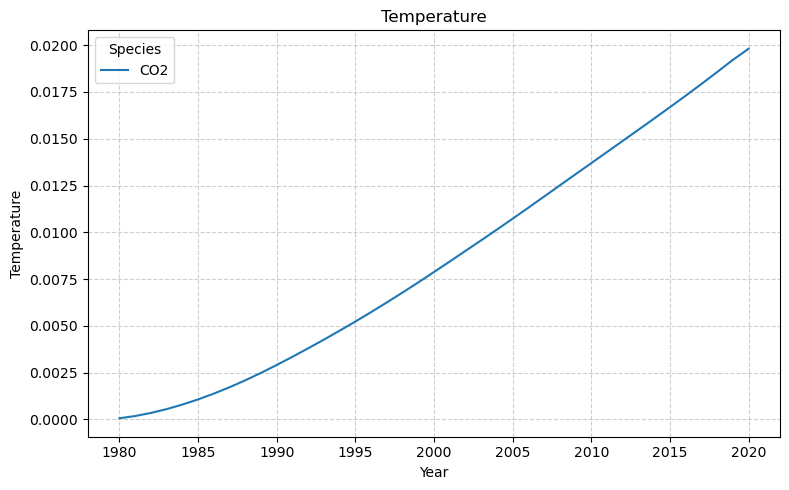

: 

In [7]:
plot_simulation_results(results_co2_373, data_var="temperature", species=["CO2"], stacked=False)
#plot_simulation_results(results_cont_ext, data_var="temperature", species=["Contrails"], stacked=False)

<Axes: title={'center': 'Temperature'}, xlabel='Year', ylabel='Temperature'>

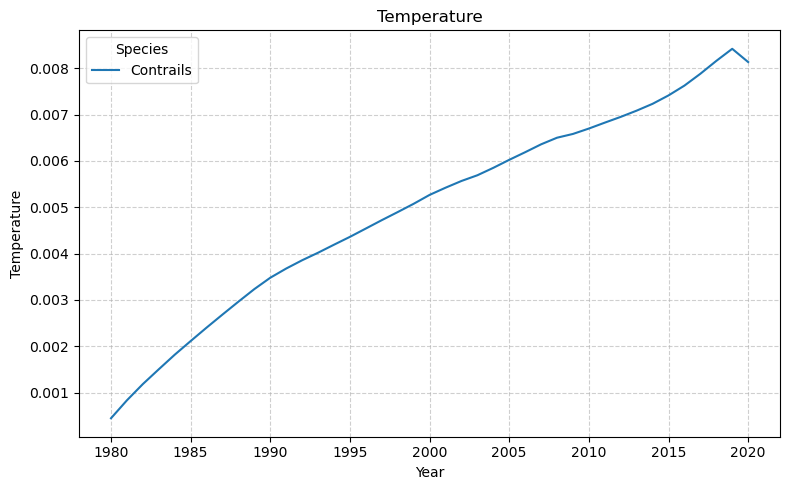

: 

In [13]:
plot_simulation_results(results_full, data_var="temperature", species=["Contrails"], stacked=False)

# Weighted runs

In [4]:
species_settings2 = { "CO2" : {"lambda": 0.73} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 0.59} 
                                      
    }

model_settings = {"step" : 1,
                  "scaling" : "",
                  "weights" : {"North America": 1,
                       "Atlantic region": 1.0,
                       "South America": 1.0,
                       "Pacific": 1.0,
                       "Far North": 1.0,
                       "Europe": 1,
                       "Africa and Middle East": 1.0,
                       "Asia": 1.0,
                       "Oceania": 1.0}
                 }
model_settings = {"step" : 1,
                  "scaling" : "", 
                  "weights" : {}
                 }

{'lambda': 0.73, 'rf_method': 'Etminan_2016'}
Saved scaled emissions to oac_inputs/mat_generated_nc_1940.nc

[DEBUG] Generated inventory for 1940:
  Target emission from CSV: 3.513589e+10 kg
  Inventory total CO2: 3.513589e+10 kg
  Ratio: 1.000000
Saved scaled emissions to oac_inputs/mat_generated_nc_1941.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1942.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1943.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1944.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1945.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1946.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1947.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1948.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1949.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1950.nc

[DEBUG] Generated inventory for 1950:
  Target emission from CSV: 7.586232e+10 kg
  Inventory total CO2: 7.586232e+10 kg
  Ratio: 1


[DEBUG] Generated inventory for 2019:
  Target emission from CSV: 1.127477e+12 kg
  Inventory total CO2: 1.127477e+12 kg
  Ratio: 1.000000
79
TOML file written to oac_run.toml

DEBUG SUMMARY: CO2 EMISSIONS IN GENERATED INVENTORIES
Number of inventories: 80
Year range: 1940 to 2019
Total cumulative CO2: 3.648280e+13 kg = 36.48 Tg
First year (1940): 3.513589e+10 kg = 0.0351 Tg
Last year (2019): 1.127477e+12 kg = 1.1275 Tg
Mean annual: 4.560350e+11 kg = 0.4560 Tg



The computed output is not for scientific purposes until release of our publication.
Amongst others, the climate impact of longer species lifetimes in the stratosphere is not considered.


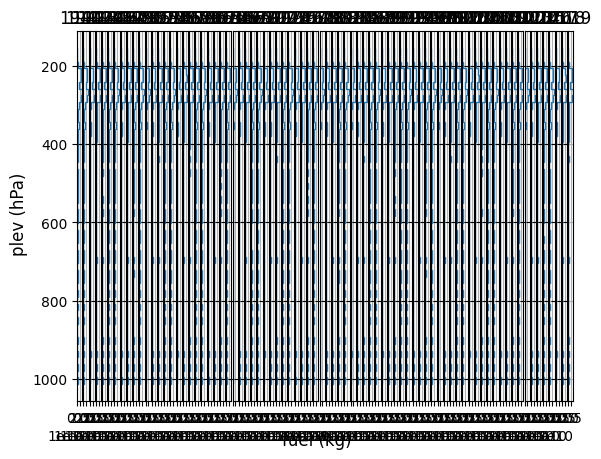

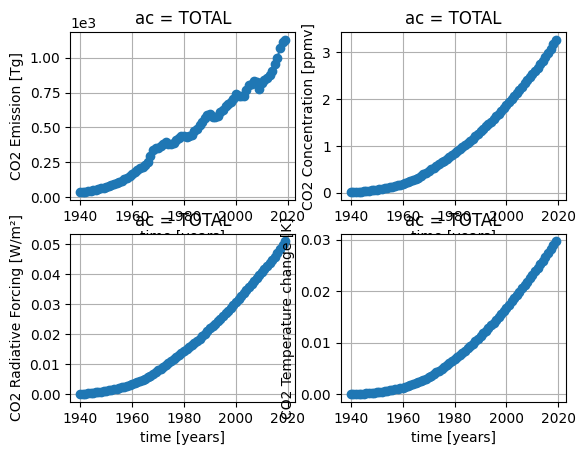

{'efficacy': 0.59}
Saved scaled emissions to oac_inputs/mat_generated_nc_1940.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1941.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1942.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1943.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1944.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1945.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1946.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1947.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1948.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1949.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1950.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1951.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1952.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1953.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1954.nc
Saved scaled emissions to oac_inputs/mat_generated_

KeyboardInterrupt: 

In [5]:
climate_model = 'OAC'
results = AviationClimateSimulation(climate_model, start_year, end_year,species_inventory,species_settings2, model_settings).run(return_xr = True)

<Axes: title={'center': 'CO2'}, xlabel='Year', ylabel='Temperature'>

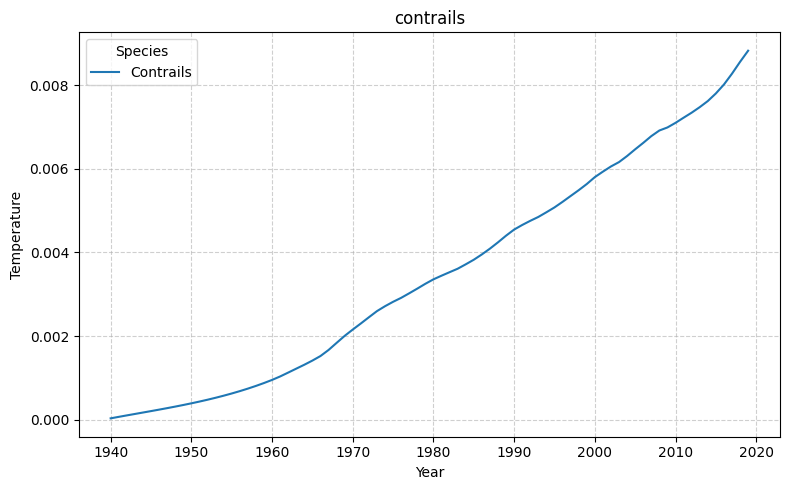

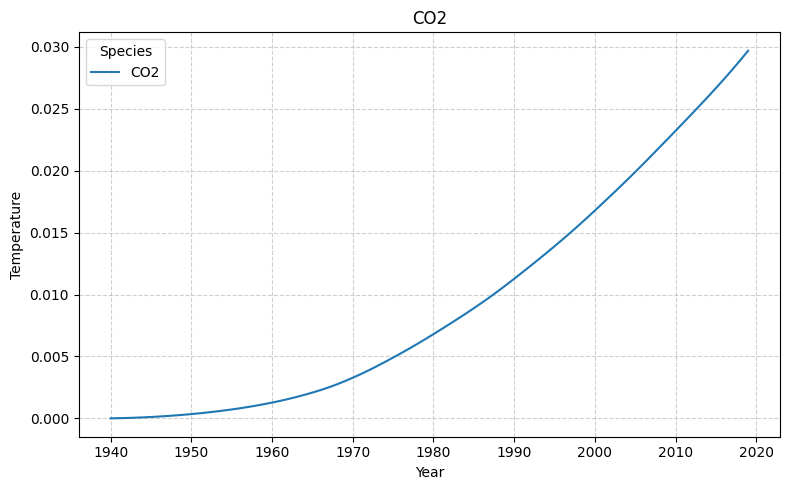

In [5]:
plot_simulation_results(results, data_var="temperature", species=["Contrails"],title = "contrails",stacked=False)
plot_simulation_results(results, data_var="temperature", species=["CO2"],title = "CO2",stacked=False)

In [5]:
results_cont_w = results_co2_373

<Axes: title={'center': 'weighted contrails'}, xlabel='Year', ylabel='Temperature'>

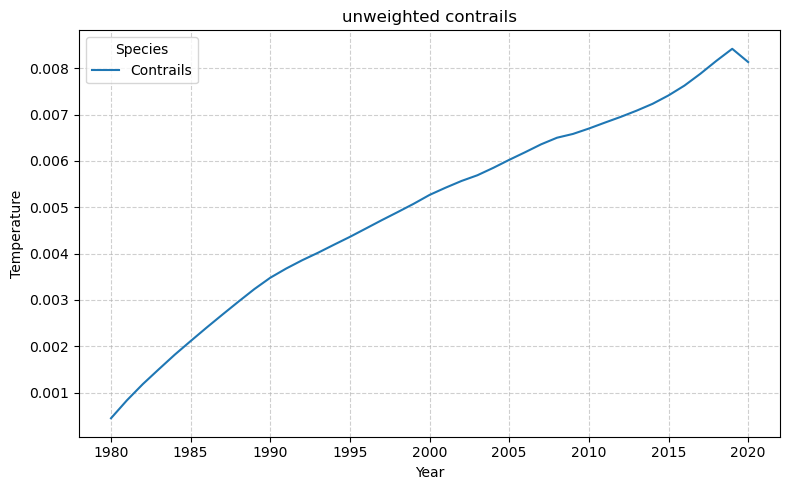

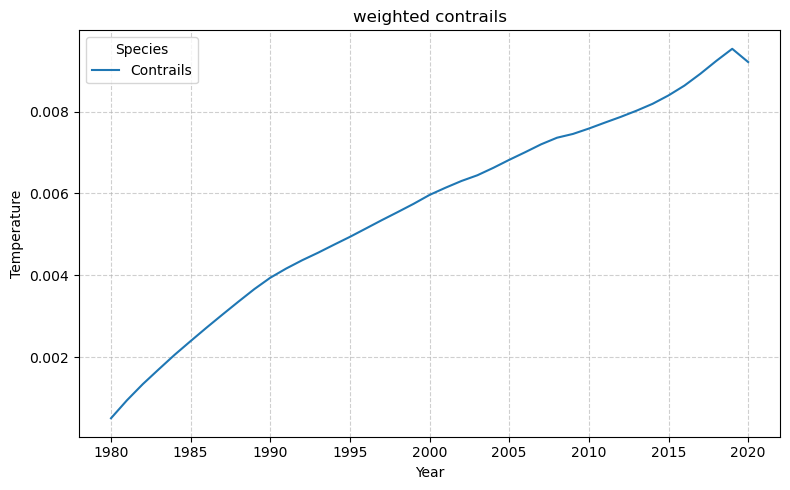

In [8]:
plot_simulation_results(results_full, data_var="temperature", species=["Contrails"],title = "unweighted contrails",stacked=False)
plot_simulation_results(results_cont_w, data_var="temperature", species=["Contrails"],title = "weighted contrails",stacked=False)

In [14]:
import xarray as xr
import matplotlib.pyplot as plt

In [13]:
contrails_temp_uw = results_full["temperature"].sel(species="Contrails")
contrails_temp_w = results_cont_w["temperature"].sel(species="Contrails")

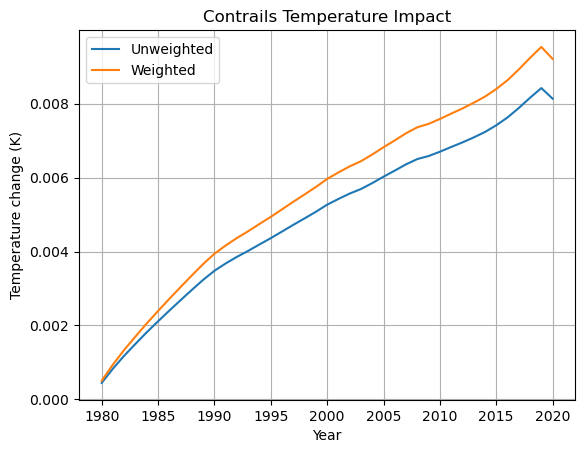

In [15]:
plt.figure()
plt.plot(contrails_temp_uw['year'], contrails_temp_uw, label='Unweighted')
plt.plot(contrails_temp_w['year'], contrails_temp_w, label='Weighted')
plt.xlabel("Year")
plt.ylabel("Temperature change (K)")
plt.title("Contrails Temperature Impact")
plt.legend()
plt.grid(True)
plt.show()

# Different RF methods 
avaliable co2 rf methods - Etminan_2016 (default), IPCC_2001_1, IPCC_2001_2 and IPCC_2001_3.

In [15]:
species_settings2 = { "CO2" : {"lambda": 0.73, "rf_method" : "IPCC_2001_3"} , 
                                "H2O" : {"efficacy": 1.14} , 
                                "O3" : {"efficacy":1.37},
                                "PMO" : {"efficacy": 1.37},
                                "CH4" : {"efficacy": 1.14},
                                "Contrails" :{"efficacy": 0.59} 
                                      
    }

model_settings = {"step" : 1,
                  "scaling" : "",
                  "weights" : {}
                 }

{'lambda': 0.73, 'rf_method': 'IPCC_2001_3'}
Saved scaled emissions to oac_inputs/mat_generated_nc_1940.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1941.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1942.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1943.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1944.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1945.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1946.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1947.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1948.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1949.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1950.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1951.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1952.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1953.nc
Saved scaled emissions to oac_inputs/mat_generated_nc_1954.nc
Saved scaled emissions to

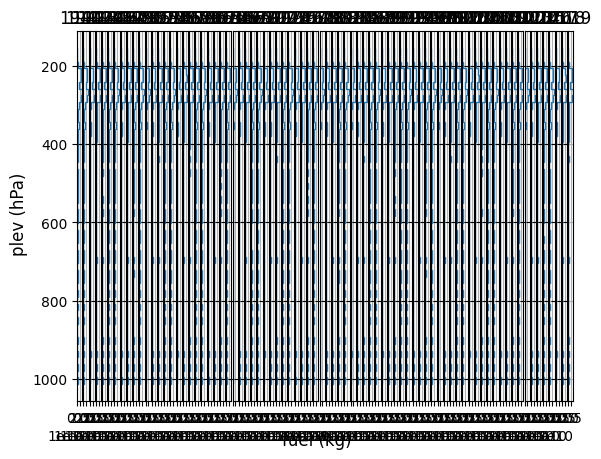

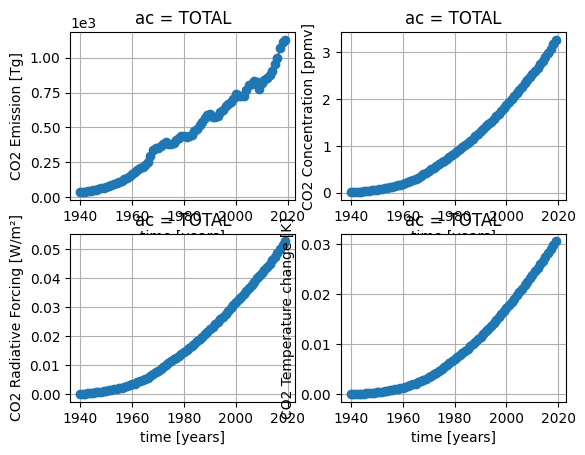

In [16]:
result_co2_ipcc_2001_3 = OpenAirClim(start_year, end_year, "CO2", species_inventory["CO2"],species_settings2["CO2"], model_settings).run(return_df=True)

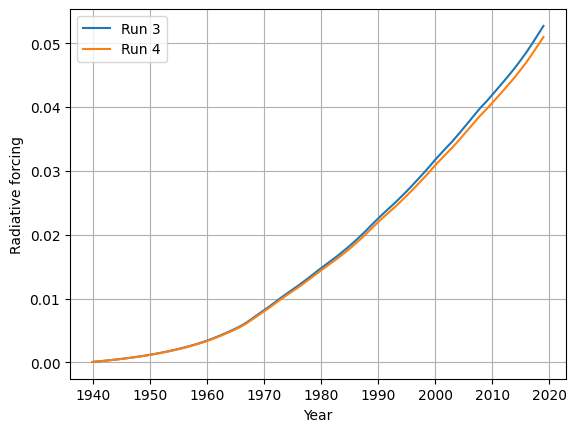

In [17]:
plt.figure()

#plt.plot(result_co2_ipcc_2001_1.index, result_co2_ipcc_2001_1["radiative_forcing"], label="IPCC_2001_1")
#plt.plot(result_co2_ipcc_2001_2.index, result_co2_ipcc_2001_2["radiative_forcing"], label="Run 2")
plt.plot(result_co2_ipcc_2001_3.index, result_co2_ipcc_2001_3["radiative_forcing"], label="Run 3")
plt.plot(result_co2_etminan.index, result_co2_etminan["radiative_forcing"], label="Run 4")

plt.xlabel("Year")
plt.ylabel("Radiative forcing")
plt.legend()
plt.grid()
plt.show()